## 1.Data Loading

In [1]:
### Set up path, no need to read file later
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
import os
#coding=utf-8
# Ignore all warnings
warnings.filterwarnings("ignore")
warnings.simplefilter("always")  # Force display of all warnings
np.seterr(all="ignore")
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False    
os.chdir(r'C:\Users\karen\Desktop\dissertation\Writing\结果打包')
data=pd.read_excel('automobile_financial_warning_2024.xlsx')

In [2]:
### View imported data
data.head()

,Stock Code,Company Name,Reporting Date,Current Ratio,Cash Ratio,Debt-to-Asset Ratio,Accounts Receivable Turnover,Inventory Turnover,Accounts Payable Turnover,Total Asset Turnover,...,Return on Equity (ROE),Profit-to-Cost Ratio,Total Asset Growth Rate,Revenue Growth Rate,Net Profit Cash Coverage Ratio,Capital Accumulation Rate,Revenue Cash Coverage Ratio,Firm Size,Total Asset Cash Recovery Rate,ST_label_T2
0,30,FuAoGuFen,2013-12-31,1.449072,0.139648,0.402571,4.682980,7.189538,4.075542,0.735239,...,0.138980,0.123633,0.134041,0.127177,-0.126878,0.131234,0.747743,22.684817,-0.010535,0
1,30,FuAoGuFen,2014-12-31,1.693147,0.293973,0.345046,4.861329,6.891466,4.040693,0.689029,...,0.141197,0.146090,0.022610,0.010848,0.535182,0.121074,0.979754,22.707175,0.049492,0
2,30,FuAoGuFen,2015-12-31,1.927048,0.474869,0.343888,3.616360,6.180370,3.200565,0.535722,...,0.098955,0.126618,0.111986,0.391913,0.635592,0.113953,1.020350,22.813323,0.041266,0
3,30,FuAoGuFen,2016-12-31,1.751659,0.473297,0.363500,4.430190,7.323275,3.431999,0.645536,...,0.117164,0.125496,0.122148,0.235995,0.887906,0.088605,0.865692,22.928567,0.066216,0
4,30,FuAoGuFen,2017-12-31,1.686763,0.467493,0.389791,4.505213,9.246369,3.408152,0.694039,...,0.129481,0.128756,0.142330,0.254516,0.565270,0.095147,0.779652,23.061638,0.044662,0


### 2、Split the dataset into the training and testing sets
### Use data from 2021 and 2023 as the training set and data from 2022–2024 as the testing set.
### Standardize the training set, and apply the same scaling parameters to the testing set to ensure consistent feature scaling.

In [3]:
### 
import pandas as pd
from sklearn.preprocessing import StandardScaler
#Convert to datetime format
data["Reporting Date"] = pd.to_datetime(data["Reporting Date"], errors="coerce")

# Filter training set(2013-2021) + testing set(2022-2024)
train = data[(data["Reporting Date"] >= "2013-01-01") & 
             (data["Reporting Date"] <= "2021-12-31")].copy()

test = data[(data["Reporting Date"] >= "2022-01-01") & 
            (data["Reporting Date"] <= "2024-12-31")].copy()

feature_cols = data.columns[3:-1]

# Initialize scaler
scaler = StandardScaler()

# Standardize training set
train[feature_cols] = scaler.fit_transform(train[feature_cols])

#  Standardize testing set using rules from training set
test[feature_cols] = scaler.transform(test[feature_cols])

# View results
print("Train set shape（2013-2021）：", train.shape)
print("Test set shape（2022-2024）：", test.shape)

Train set shape（2013-2021）： (2075, 21)
Test set shape（2022-2024）： (896, 21)


## 3. Handling Imbalanced Samples
The dataset is characterized by an imbalanced class distribution. Therefore, SMOTE is applied only to the training set to balance the classes, while the testing set is kept unchanged to ensure an unbiased evaluation of the model's predictive performance.

In [4]:
### Handle class imbalance
print("===== Training set class distribution before SMOTE =====")
print(train['ST_label_T2'].value_counts())
print("Class proportions：\n", train['ST_label_T2'].value_counts(normalize=True))

===== Training set class distribution before SMOTE =====
ST_label_T2
0    2022
1      53
Name: count, dtype: int64
Class proportions：
 ST_label_T2
0    0.974458
1    0.025542
Name: proportion, dtype: float64


In [5]:
from imblearn.over_sampling import SMOTE
feature_cols = train.columns[3:-1]
train['ST_label_T2'] = train['ST_label_T2'].astype(int)  # Convert labels to integer (0/1)
test['ST_label_T2'] = test['ST_label_T2'].astype(int)
X_train = train[feature_cols]
y_train = train['ST_label_T2']  # Target variable
X_test = test[feature_cols]
y_test = test['ST_label_T2']  # Target variable
# ========================
# Apply SMOTE (1:1 balancing)
# ========================
smote = SMOTE(random_state=50, sampling_strategy=1)  #  Set random_state for reproducibility
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# ========================
#  View balanced class distribution
# ========================
print("\n===== Training set class distribution after SMOTE =====")
print(pd.Series(y_train_balanced).value_counts())


===== Training set class distribution after SMOTE =====
ST_label_T2
0    2022
1    2022
Name: count, dtype: int64


## 4. Logistic Regression Model Training and Evaluation

Optimal Threshold： 0.6712
===== Logistic Regression Test Results（Optimal Threshold） =====
Best parameters: {'C': 0.1}
Accuracy: 0.8583
Precision: 0.1119
Recall: 1.0000
F1: 0.2013
AUC: 0.9335


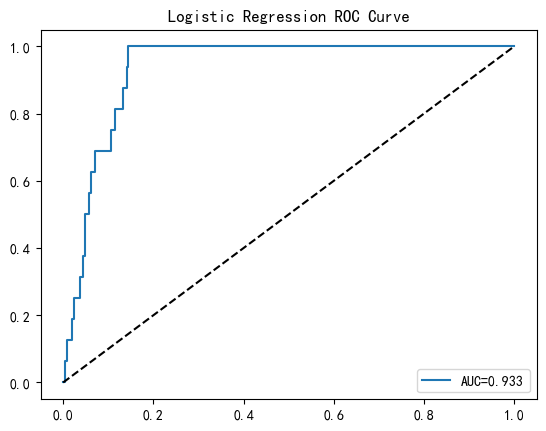

In [6]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve)

# Train the model
params = {"C": [0.1, 1, 10]}
model = LogisticRegression(
    max_iter=2000,
     random_state=50                  
 )
grid = GridSearchCV(model, params, cv=3, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train_balanced, y_train_balanced)
lr = grid.best_estimator_

#  Predict class probabilities
y_prob_lr = lr.predict_proba(X_test)[:,1]

# ========================
# Determine the optimal ROC threshold
# ========================
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

# Optimal threshold based on Youden's Index
# (Sensitivity + Specificity − 1)
optimal_idx = (tpr - fpr).argmax()
optimal_threshold = thresholds[optimal_idx]

print("Optimal Threshold：", round(optimal_threshold, 4))

# Generate predicted labels using the optimal threshold
y_pred_lr = (y_prob_lr >= optimal_threshold).astype(int)

# ========================
#  Evaluate model performance
# (using the optimal threshold)
# ========================
print("===== Logistic Regression Test Results（Optimal Threshold） =====")
print("Best parameters:", grid.best_params_)
print("Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred_lr)))
print("Precision: {:.4f}".format(precision_score(y_test, y_pred_lr)))
print("Recall: {:.4f}".format(recall_score(y_test, y_pred_lr)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_lr)))
print("AUC: {:.4f}".format(roc_auc_score(y_test, y_prob_lr)))

# Plot ROC
#plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test,y_prob_lr):.3f}")
#plt.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='red', label="最优分割点")
plt.plot([0,1],[0,1],"k--")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.show()

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
def plot_cm(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                  display_labels=["Negative", "Positive"]
    )
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

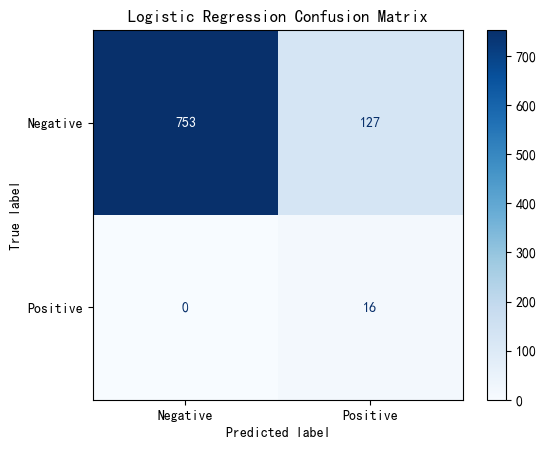

In [8]:
# Plot confusion matrix
plot_cm(y_test, y_pred_lr, "Logistic Regression Confusion Matrix")

## 5. Support Vector Machine (SVM) Model Training and Evaluation

SVM Optimal Threshold： 0.0
===== SVM Test Results (Optimal Threshold)） =====
Best parameters: {'C': 5, 'gamma': 0.1, 'kernel': 'rbf'}
Accuracy: 0.7522
Precision: 0.0598
Recall: 0.8750
F1: 0.1120
AUC: 0.8695


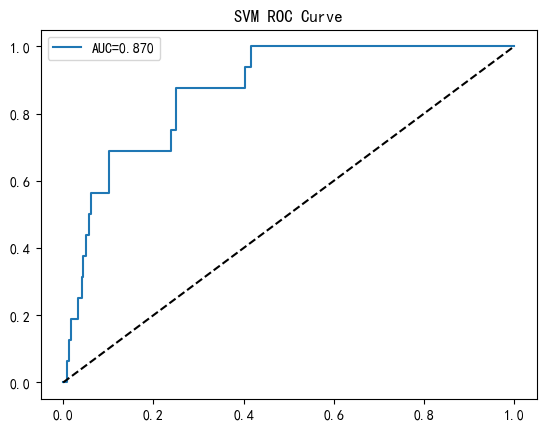

In [9]:
from sklearn.svm import SVC
params = {
    'C': [0.1, 0.5, 1, 2, 5],            # Regularization parameter
    'kernel': ['rbf', 'linear'],         # Kernel function
    'gamma': ['scale', 'auto', 0.01, 0.1] # Kernel coefficient

}
model = SVC(probability=True)
grid = GridSearchCV(model, params, cv=3, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train_balanced, y_train_balanced)
svm = grid.best_estimator_

# Predict class probabilities
y_prob_svm = svm.predict_proba(X_test)[:,1]

# ========================
# Determine the optimal ROC threshold
# (Youden's Index)
# ========================
fpr, tpr, thresholds = roc_curve(y_test, y_prob_svm)
optimal_idx = (tpr - fpr).argmax()           # Optimal index
optimal_threshold = thresholds[optimal_idx] # Optimal threshold
print("SVM Optimal Threshold：", round(optimal_threshold, 4))

# Generate predicted labels using the optimal threshold
y_pred_svm = (y_prob_svm >= optimal_threshold).astype(int)

# ========================
# Evaluate model performance
# (using the optimal threshold)
# ========================
print("===== SVM Test Results (Optimal Threshold)） =====")
print("Best parameters:", grid.best_params_)
print("Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred_svm)))
print("Precision: {:.4f}".format(precision_score(y_test, y_pred_svm)))
print("Recall: {:.4f}".format(recall_score(y_test, y_pred_svm)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_svm)))
print("AUC: {:.4f}".format(roc_auc_score(y_test, y_prob_svm)))

# Plot ROC 
#plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test,y_prob_svm):.3f}")
#plt.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='red', label='Optimal Threshold') 
plt.plot([0,1],[0,1],"k--")
plt.title("SVM ROC Curve")
plt.legend()
plt.show()

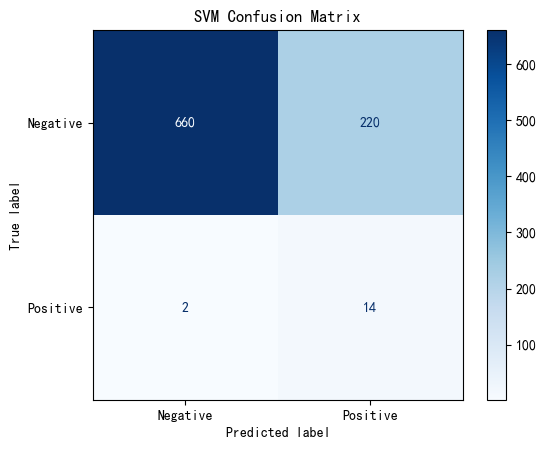

In [10]:
# Plot confusion matrix
plot_cm(y_test, y_pred_svm, "SVM Confusion Matrix")

## 6. Random Forest Model Training and Evaluation

Random Forest Optimal Threshold： 0.3615
===== Random Forest Test Results (Optimal Threshold) =====
Best parameters: {'max_depth': 9, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Accuracy: 0.8728
Precision: 0.1172
Recall: 0.9375
F1: 0.2083
AUC: 0.9363


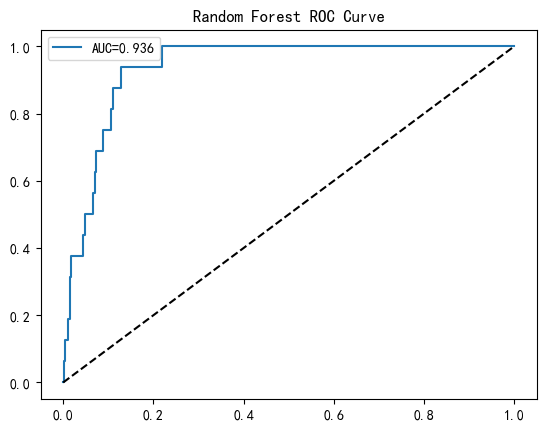

In [11]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve)

#params = {"n_estimators": [100], "max_depth": [5, 10]}

params = {
    'n_estimators': [100, 200],     # Number of trees
    'max_depth': [3, 5, 7, 9],         # Maximum tree depth
    'min_samples_split': [2, 5],      # Minimum samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]     # Minimum samples required at a leaf node

}
model = RandomForestClassifier(random_state=50)
grid = GridSearchCV(model, params, cv=3, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train_balanced, y_train_balanced)
rf = grid.best_estimator_

# Predict class probabilities
y_prob_rf = rf.predict_proba(X_test)[:,1]

# ========================
# Determine the optimal ROC threshold
# (Youden's Index)
# ========================
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
optimal_idx = (tpr - fpr).argmax()           # Optimal index
optimal_threshold = thresholds[optimal_idx]  # Optimal threshold
print("Random Forest Optimal Threshold：", round(optimal_threshold, 4))

#  Generate predicted labels using the optimal threshold
y_pred_rf = (y_prob_rf >= optimal_threshold).astype(int)

# ========================
# Evaluate model performance
# (using the optimal threshold)
# ========================
print("===== Random Forest Test Results (Optimal Threshold) =====")
print("Best parameters:", grid.best_params_)
print("Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred_rf)))
print("Precision: {:.4f}".format(precision_score(y_test, y_pred_rf)))
print("Recall: {:.4f}".format(recall_score(y_test, y_pred_rf)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_rf)))
print("AUC: {:.4f}".format(roc_auc_score(y_test, y_prob_rf)))

# Plot ROC curve and highlight the optimal threshold
#plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test,y_prob_rf):.3f}")
#plt.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='red', label='最优分割点') 
plt.plot([0,1],[0,1],"k--")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.show()

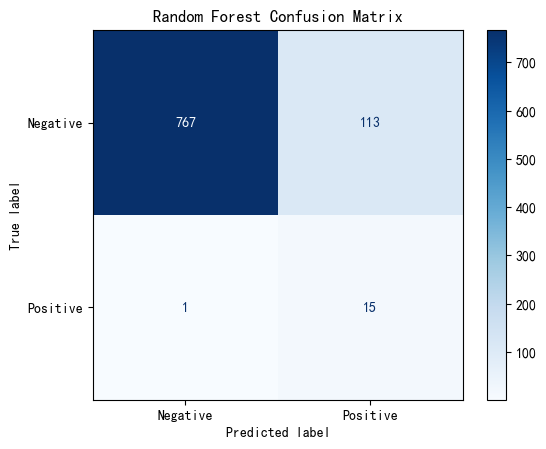

In [12]:
# Plot confusion matrix
plot_cm(y_test, y_pred_rf, "Random Forest Confusion Matrix")

##7.XGBoost Model Training and Evaluation

In [13]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


C:\Users\karen\AppData\Roaming\Python\Python313\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedWriter name=5>
  res = process_handler(cmd, _system_body)
C:\Users\karen\AppData\Roaming\Python\Python313\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=6>
  res = process_handler(cmd, _system_body)
C:\Users\karen\AppData\Roaming\Python\Python313\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=7>
  res = process_handler(cmd, _system_body)


XGB optimal threshold： 0.1644
===== XGBoost Test Results (Optimal Threshold) =====
Best parameters: {'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.8}
Accuracy: 0.8906
Precision: 0.1273
Recall: 0.8750
F1: 0.2222
AUC: 0.9286


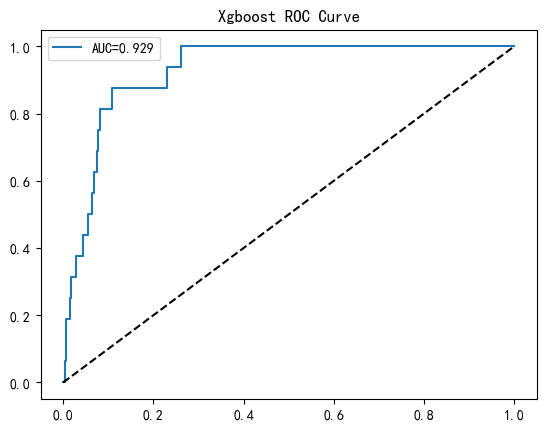

In [14]:
from xgboost import XGBClassifier

params = {
    'n_estimators': [100, 200],
    'max_depth': [2,3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9],
    'min_child_weight': [1, 3,5],
    'gamma': [0.1, 0.2]
}
model = XGBClassifier(random_state=50)
grid = GridSearchCV(model, params, cv=3, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train_balanced, y_train_balanced)
xgb = grid.best_estimator_

# Predict class probabilities
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

# ========================
# Determine the optimal ROC threshold
# (Youden's Index)
# ========================
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)
optimal_idx = (tpr - fpr).argmax()
optimal_threshold = thresholds[optimal_idx]

# Generate predicted labels using the optimal threshold
y_pred_xgb = (y_prob_xgb >= optimal_threshold).astype(int)

# Display the optimal threshold
print("XGB optimal threshold：", round(optimal_threshold, 4))

# Evaluate model performance
# (using the optimal threshold)
print("===== XGBoost Test Results (Optimal Threshold) =====")
print("Best parameters:", grid.best_params_)
print("Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred_xgb)))
print("Precision: {:.4f}".format(precision_score(y_test, y_pred_xgb)))
print("Recall: {:.4f}".format(recall_score(y_test, y_pred_xgb)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_xgb)))
print("AUC: {:.4f}".format(roc_auc_score(y_test, y_prob_xgb)))

# Plot ROC curve
#plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test,y_prob_xgb):.3f}")
#plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color="red", label="optimal threshold") 
plt.plot([0,1],[0,1],"k--")
plt.title("Xgboost ROC Curve")
plt.legend()
plt.show()

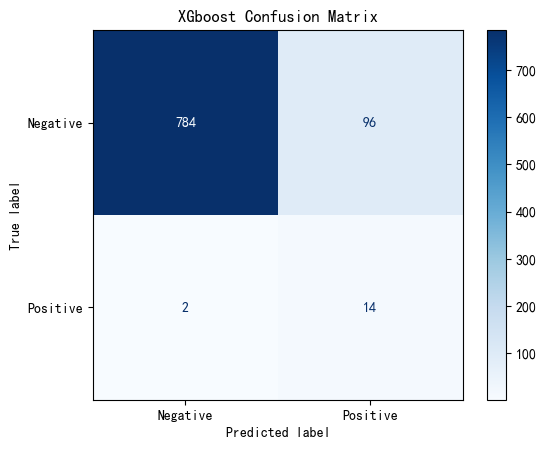

In [15]:
# Plot confusion matrix
plot_cm(y_test, y_pred_xgb, "XGboost Confusion Matrix")

## 8. LightGBM Model Training and Evaluation

In [16]:
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


C:\Users\karen\AppData\Roaming\Python\Python313\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedWriter name=5>
  res = process_handler(cmd, _system_body)
C:\Users\karen\AppData\Roaming\Python\Python313\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=6>
  res = process_handler(cmd, _system_body)
C:\Users\karen\AppData\Roaming\Python\Python313\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=7>
  res = process_handler(cmd, _system_body)


 LightGBM Optimal Threshold： 0.0083
===== LightGBM Test Results (Optimal Threshold) =====
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
Accuracy: 0.8538
Precision: 0.0922
Recall: 0.8125
F1: 0.1656
AUC: 0.8904


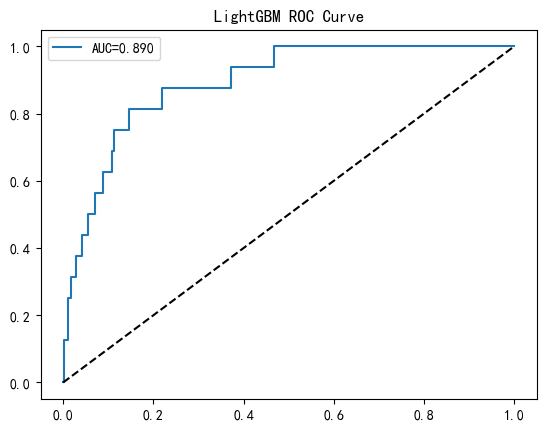

In [17]:
from lightgbm import LGBMClassifier

# Hyperparameter tuning
params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9]
}

# Disable training logs
model = LGBMClassifier(random_state=50, verbose=-1)

# Perform grid search
grid = GridSearchCV(model, params, cv=3, scoring="roc_auc", n_jobs=-1, verbose=0)
grid.fit(X_train_balanced, y_train_balanced)
lgb = grid.best_estimator_

# Predict class probabilities
y_prob_lgb = lgb.predict_proba(X_test)[:,1]

# ========================
#  Determine the optimal ROC threshold
# (Youden's Index)
# ========================
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lgb)
optimal_idx = (tpr - fpr).argmax()
optimal_threshold = thresholds[optimal_idx]
y_pred_lgb = (y_prob_lgb >= optimal_threshold).astype(int)

# Generate predicted labels using the optimal threshold
print(" LightGBM Optimal Threshold：", round(optimal_threshold, 4))

# Model evaluation
print("===== LightGBM Test Results (Optimal Threshold) =====")
print("Best parameters:", grid.best_params_)
print("Accuracy: {:.4f}".format(accuracy_score(y_test, y_pred_lgb)))
print("Precision: {:.4f}".format(precision_score(y_test, y_pred_lgb)))
print("Recall: {:.4f}".format(recall_score(y_test, y_pred_lgb)))
print("F1: {:.4f}".format(f1_score(y_test, y_pred_lgb)))
print("AUC: {:.4f}".format(roc_auc_score(y_test, y_prob_lgb)))

# Plot ROC curve
#plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test,y_prob_lgb):.3f}")
#plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', label='Optimal Threshold')
plt.plot([0,1],[0,1],"k--")
plt.title("LightGBM ROC Curve")
plt.legend()
plt.show()

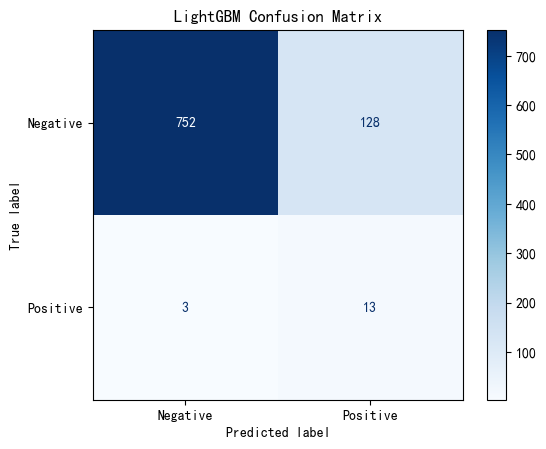

In [18]:
# Plot confusion matrix
plot_cm(y_test, y_pred_lgb, "LightGBM Confusion Matrix")

## ## 9. Comparison of the five Model Performance

In [19]:
# Save the performance metrics of the five models
results = pd.DataFrame({
    'Model': ['LR', 'SVM', 'RF', 'XGB', 'LGB'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lgb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_lgb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_lgb)
    ],
    'F1': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_lgb)
    ],
    'AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_svm),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_lgb)
    ]
})

# Display results with four decimal places
results = results.round(4)
print("\n==================== Model Performance Summary ====================\n")
results


==================== Model Performance Summary ====================



,Model,Accuracy,Precision,Recall,F1,AUC
0,LR,0.8583,0.1119,1.0000,0.2013,0.9335
1,SVM,0.7522,0.0598,0.8750,0.1120,0.8695
2,RF,0.8728,0.1172,0.9375,0.2083,0.9363
3,XGB,0.8906,0.1273,0.8750,0.2222,0.9286
4,LGB,0.8538,0.0922,0.8125,0.1656,0.8904


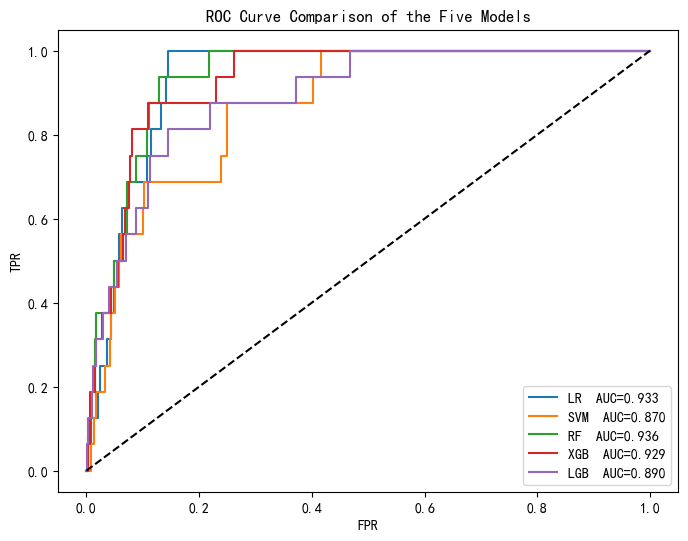

In [20]:
plt.figure(figsize=(8, 6))

# Plot ROC curves for all models
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
plt.plot(fpr_lr, tpr_lr, label=f'LR  AUC={roc_auc_score(y_test, y_prob_lr):.3f}')

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
plt.plot(fpr_svm, tpr_svm, label=f'SVM  AUC={roc_auc_score(y_test, y_prob_svm):.3f}')

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f'RF  AUC={roc_auc_score(y_test, y_prob_rf):.3f}')

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGB  AUC={roc_auc_score(y_test, y_prob_xgb):.3f}')

fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_prob_lgb)
plt.plot(fpr_lgb, tpr_lgb, label=f'LGB  AUC={roc_auc_score(y_test, y_prob_lgb):.3f}')

plt.plot([0,1],[0,1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve Comparison of the Five Models')
plt.legend()
plt.savefig("ROC_Curve_Comparison_Five_Models.png", dpi=300, bbox_inches="tight")
plt.show()


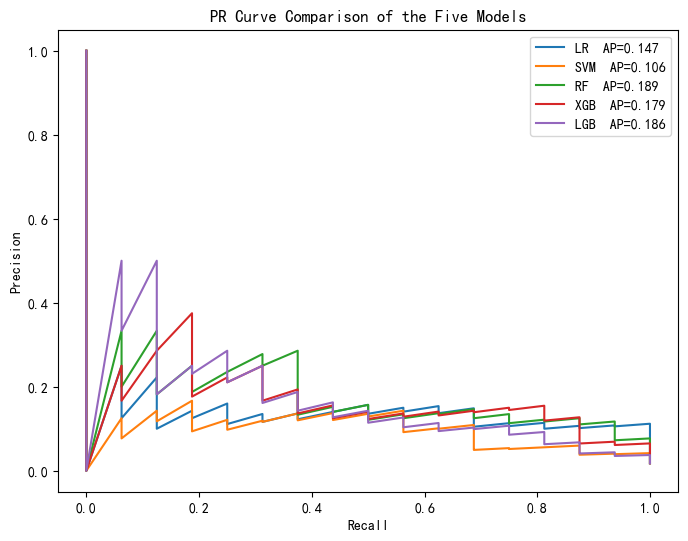

In [21]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8, 6))

# Plot PR curves for all models
# Logistic Regression
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
ap_lr = average_precision_score(y_test, y_prob_lr)
plt.plot(recall_lr, precision_lr, label=f'LR  AP={ap_lr:.3f}')

# Support Vector Machine
precision_svm, recall_svm, _ = precision_recall_curve(y_test, y_prob_svm)
ap_svm = average_precision_score(y_test, y_prob_svm)
plt.plot(recall_svm, precision_svm, label=f'SVM  AP={ap_svm:.3f}')

# Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
ap_rf = average_precision_score(y_test, y_prob_rf)
plt.plot(recall_rf, precision_rf, label=f'RF  AP={ap_rf:.3f}')

# XGBoost
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
ap_xgb = average_precision_score(y_test, y_prob_xgb)
plt.plot(recall_xgb, precision_xgb, label=f'XGB  AP={ap_xgb:.3f}')

# LightGBM
precision_lgb, recall_lgb, _ = precision_recall_curve(y_test, y_prob_lgb)
ap_lgb = average_precision_score(y_test, y_prob_lgb)
plt.plot(recall_lgb, precision_lgb, label=f'LGB  AP={ap_lgb:.3f}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curve Comparison of the Five Models')
plt.legend()
plt.savefig("PR_Curve_Comparison_Five_Models.png", dpi=300, bbox_inches="tight")
plt.show()

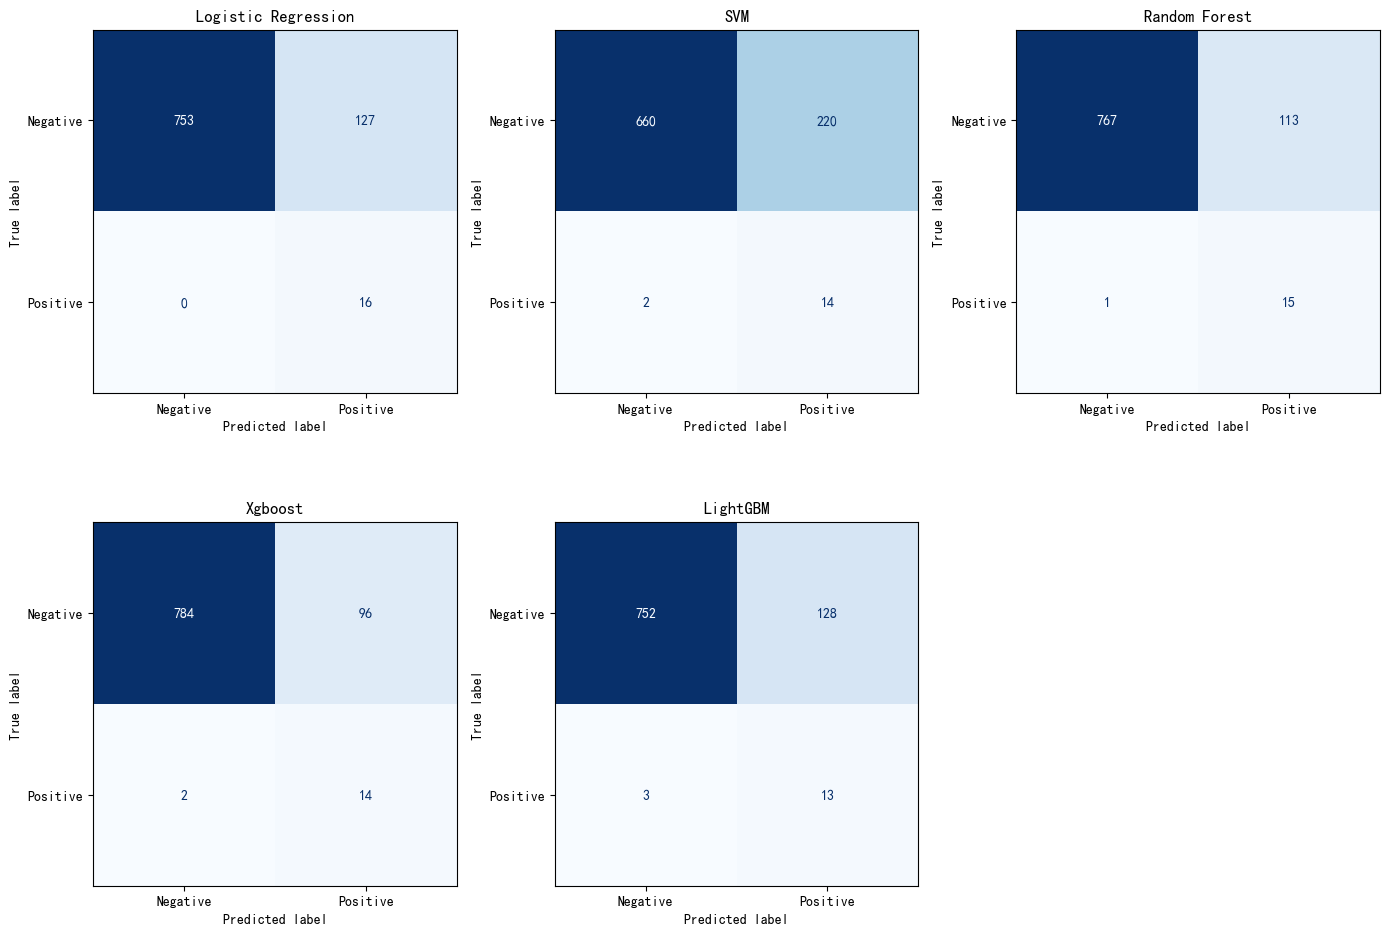

<Figure size 600x500 with 0 Axes>

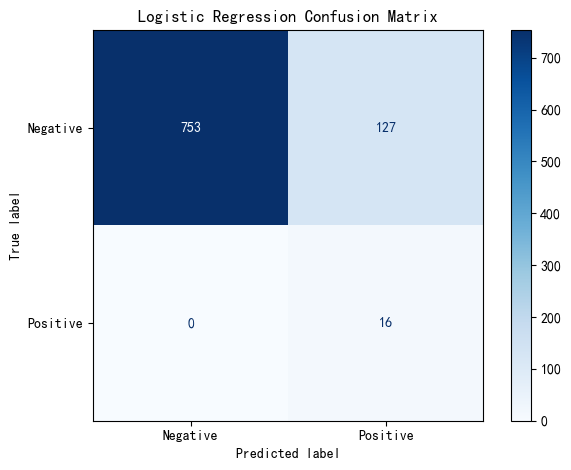

<Figure size 600x500 with 0 Axes>

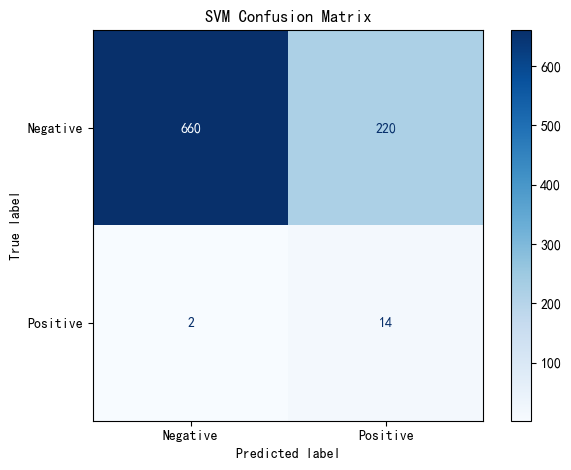

<Figure size 600x500 with 0 Axes>

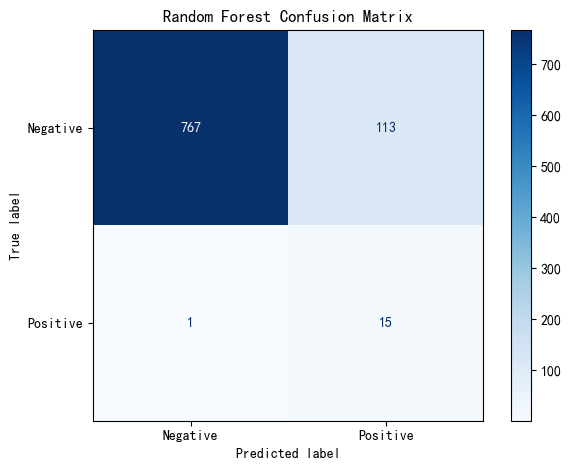

<Figure size 600x500 with 0 Axes>

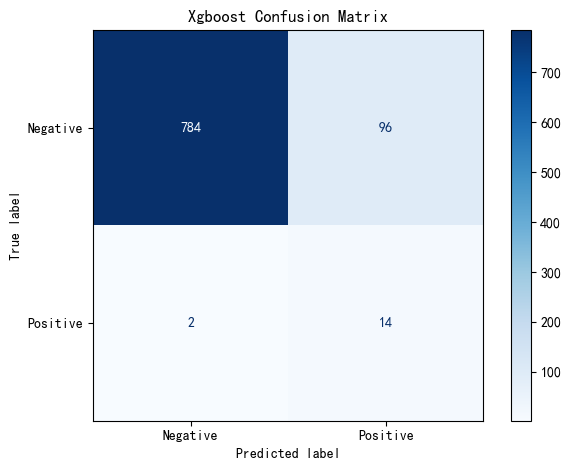

<Figure size 600x500 with 0 Axes>

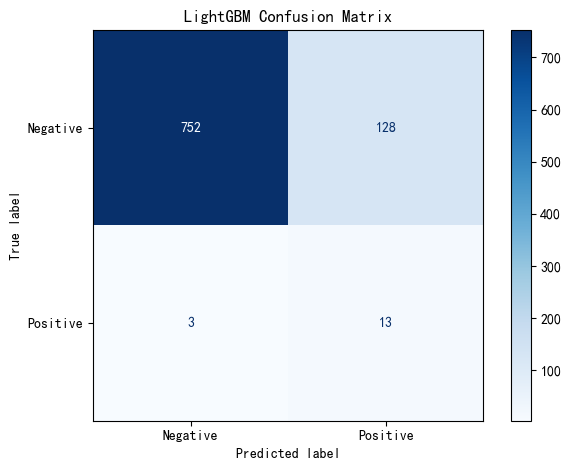

In [22]:
# Model information
models_info = [
    ("Logistic Regression", y_pred_lr, "lr_cm"),
    ("SVM", y_pred_svm, "svm_cm"),
    ("Random Forest", y_pred_rf, "rf_cm"),
    ("Xgboost", y_pred_xgb, "xgb_cm"),
    ("LightGBM", y_pred_lgb, "lgb_cm")  
]

# Plot confusion matrices in a 2×3 grid
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, y_pred, _) in enumerate(models_info):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
    disp.plot(ax=axes[idx], cmap=plt.cm.Blues, colorbar=False)
    axes[idx].set_title(name, fontsize=12)

axes[5].set_visible(False)

plt.tight_layout()
# Save the combined figure
plt.savefig("all_models_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()



# Plot each confusion matrix separately
for name, y_pred, filename in models_info:
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"{name} Confusion Matrix")
    plt.tight_layout()
   # Save each figure individually
    plt.savefig(f"{filename}.png", dpi=300, bbox_inches="tight")
    plt.show()

## 10. SHAP Analysis Based on the Best-Performing Model (Random Forest)

In [ ]:
!pip install shap

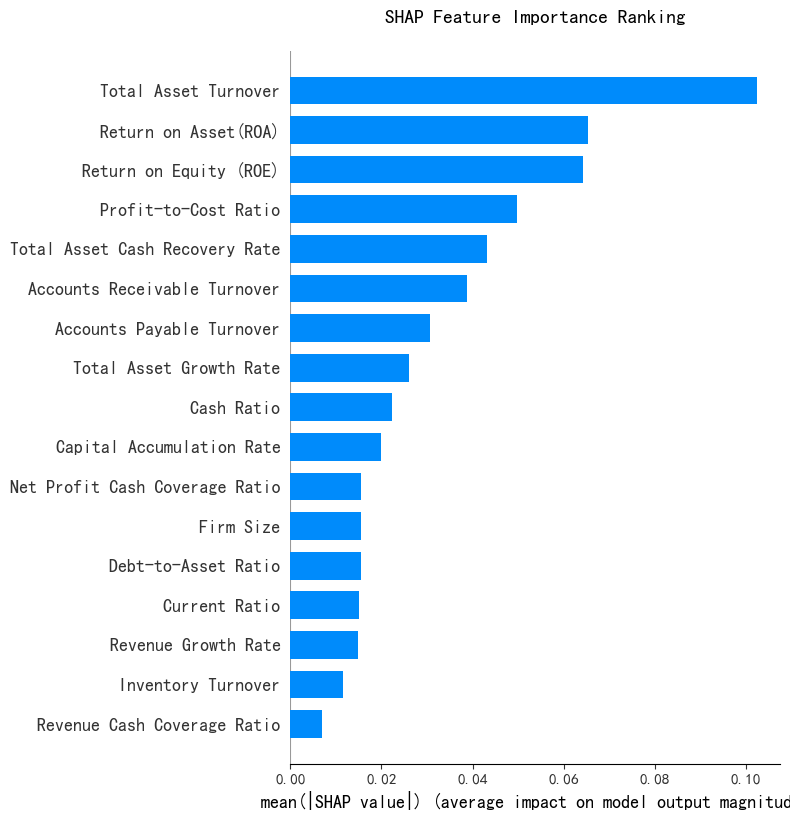

In [24]:
import shap
import matplotlib.pyplot as plt
import numpy as np

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values = shap_values[:, :, 1]

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance Ranking", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig("shap_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

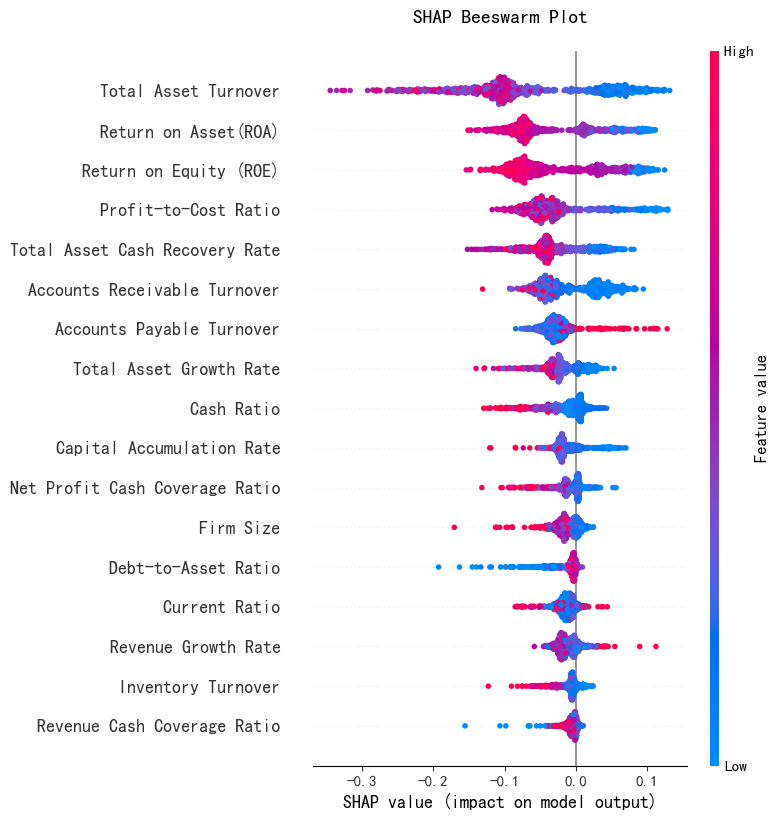

In [25]:
#  2. SHAP Beeswarm Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_test, 
    show=False 
)

# Title and Layout
plt.title("SHAP Beeswarm Plot", fontsize=14, pad=20)
plt.tight_layout()

# Save Figure
plt.savefig("shap_beeswarm.png", dpi=300, bbox_inches="tight")  
# Display Figure
plt.show()

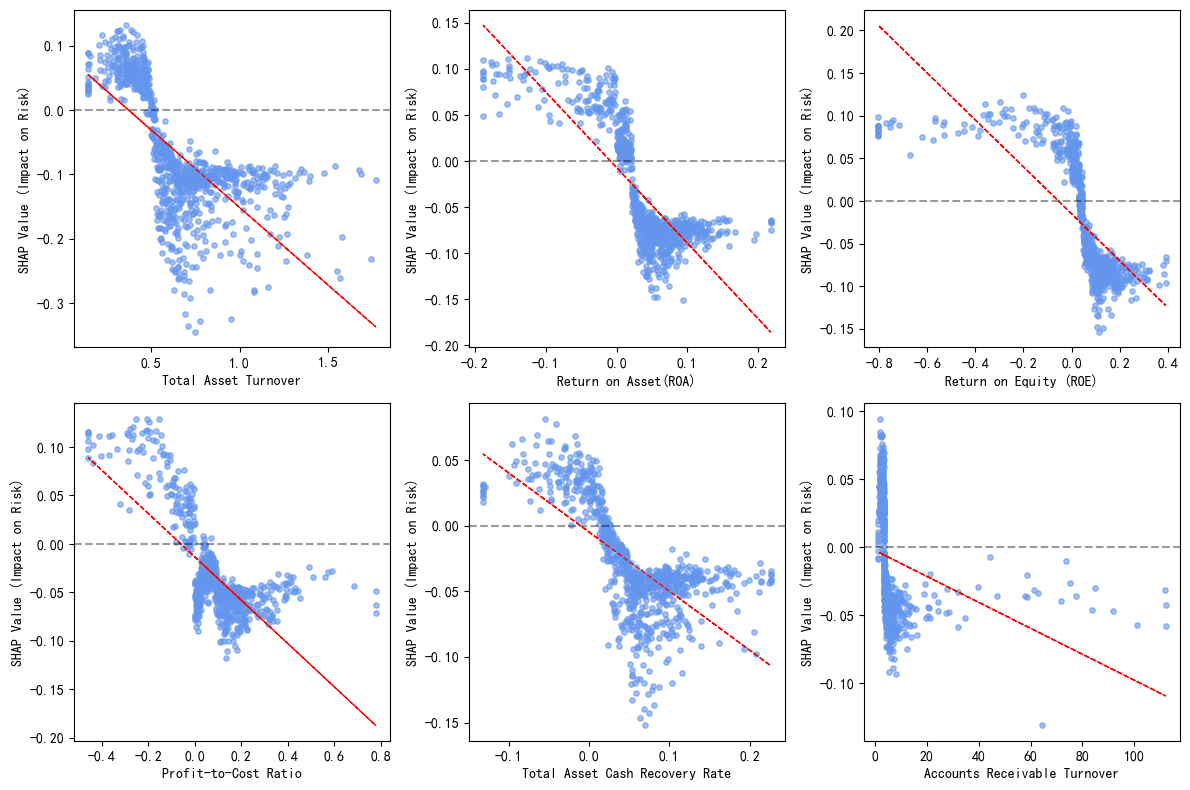

In [26]:
from sklearn.linear_model import LinearRegression
# Since the data were standardized, restore the original values for the x-axis
X_test_original = scaler.inverse_transform(X_test)
X_test_original = pd.DataFrame(X_test_original, columns=X_test.columns)
shap_importance = np.abs(shap_values).mean(0)
top6_idx = np.argsort(shap_importance)[-6:][::-1]
top6_features = X_test.columns[top6_idx]
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

# Store results
results = []

for idx, feat in enumerate(top6_features):
    x = X_test_original[feat].values
    y = shap_values[:, X_test.columns.get_loc(feat)]

    # Scatter Plot
    axes[idx].scatter(x, y, c="cornflowerblue", alpha=0.6, s=15)

    # Linear Regression Fit
    lr = LinearRegression()
    lr.fit(x.reshape(-1, 1), y)
    y_pred = lr.predict(x.reshape(-1, 1))

    # Save Results
    results.append({
        "Feature": feat,
        "Slope": lr.coef_[0],
        "Intercept": lr.intercept_
    })

    # Regression Line
    axes[idx].plot(x, y_pred, color="red", linewidth=1, linestyle='--')
    axes[idx].axhline(0, color="black", linestyle="--", alpha=0.4)

    axes[idx].set_xlabel(feat)
    axes[idx].set_ylabel("SHAP Value (Impact on Risk)")

plt.tight_layout()
plt.savefig("shap_top6_dependence.png", dpi=300, bbox_inches="tight")  
plt.show()


In [27]:
## 11. Five-level Financial Risk Warning System and Seres Historical Validation

#The Random Forest predicted probability is converted into five warning levels using fixed, interpretable cut-offs. The optimal Random Forest classification threshold (0.3615) separates Moderate Warning from High Warning.


In [28]:
import numpy as np
import pandas as pd

# =============================================================
# Five-level Financial Risk Warning System (fixed cut-off method)
# =============================================================
# The cut-offs follow the warning framework adopted in Chapter 5:
# [0.0000, 0.1000)  -> No Warning
# [0.1000, 0.2000)  -> Low Warning
# [0.2000, 0.3615)  -> Moderate Warning
# [0.3615, 0.6000)  -> High Warning
# [0.6000, 1.0000]  -> Severe Warning

RF_WARNING_THRESHOLD = 0.3615


def assign_warning_level(prob):
    """Convert an RF distress probability into one of five warning levels."""
    if pd.isna(prob):
        return np.nan
    if not 0 <= prob <= 1:
        raise ValueError(f"Risk probability must be between 0 and 1, received {prob}.")
    if prob < 0.1000:
        return "No Warning"
    elif prob < 0.2000:
        return "Low Warning"
    elif prob < RF_WARNING_THRESHOLD:
        return "Moderate Warning"
    elif prob < 0.6000:
        return "High Warning"
    else:
        return "Severe Warning"


# Display the adopted warning framework
warning_framework = pd.DataFrame({
    "Risk Score Range": [
        "0.0000-0.1000",
        "0.1000-0.2000",
        "0.2000-0.3615",
        "0.3615-0.6000",
        "0.6000-1.0000"
    ],
    "Warning Level": [
        "No Warning",
        "Low Warning",
        "Moderate Warning",
        "High Warning",
        "Severe Warning"
    ]
})

display(warning_framework)

# Generate five-level warnings for the unchanged test set
# y_prob_rf was generated by the trained Random Forest model in Section 6.
y_prob_rf = rf.predict_proba(X_test)[:, 1]

warning_results = pd.DataFrame({
    "Actual_Label": np.asarray(y_test),
    "RF_Risk_Probability": y_prob_rf,
    "RF_Binary_Prediction": (y_prob_rf >= RF_WARNING_THRESHOLD).astype(int)
}, index=y_test.index)

warning_results["Warning_Level"] = (
    warning_results["RF_Risk_Probability"].apply(assign_warning_level)
)
warning_results["RF_Risk_Probability"] = (
    warning_results["RF_Risk_Probability"].round(4)
)

print(f"RF classification threshold used in the warning system: {RF_WARNING_THRESHOLD:.4f}")
display(warning_results.head(20))

,Risk Score Range,Warning Level
0,0.0000-0.1000,No Warning
1,0.1000-0.2000,Low Warning
2,0.2000-0.3615,Moderate Warning
3,0.3615-0.6000,High Warning
4,0.6000-1.0000,Severe Warning


RF classification threshold used in the warning system: 0.3615


,Actual_Label,RF_Risk_Probability,RF_Binary_Prediction,Warning_Level
9,0,0.0384,0,No Warning
10,0,0.0061,0,No Warning
11,0,0.0052,0,No Warning
21,0,0.1718,0,Low Warning
22,0,0.0003,0,No Warning
23,0,0.0053,0,No Warning
33,0,0.0245,0,No Warning
34,0,0.0052,0,No Warning
35,0,0.0003,0,No Warning
45,0,0.0174,0,No Warning


In [29]:
# ======================================
# Five-level warning distribution
# ======================================
warning_order = [
    "No Warning",
    "Low Warning",
    "Moderate Warning",
    "High Warning",
    "Severe Warning"
]

warning_summary = (
    warning_results["Warning_Level"]
    .value_counts()
    .reindex(warning_order, fill_value=0)
    .rename_axis("Warning Level")
    .reset_index(name="Number of Firm-year Observations")
)

warning_summary["Percentage (%)"] = (
    warning_summary["Number of Firm-year Observations"]
    / warning_summary["Number of Firm-year Observations"].sum()
    * 100
).round(2)

display(warning_summary)

,Warning Level,Number of Firm-year Observations,Percentage (%)
0,No Warning,575,64.17
1,Low Warning,111,12.39
2,Moderate Warning,82,9.15
3,High Warning,52,5.80
4,Severe Warning,76,8.48


In [30]:
# ======================================
# Warning level versus actual T-2 label
# ======================================
cross_table = pd.crosstab(
    warning_results["Warning_Level"],
    warning_results["Actual_Label"],
    margins=True
).reindex(warning_order + ["All"], fill_value=0)

# Rename only the label columns that are present
cross_table = cross_table.rename(columns={
    0: "Healthy (0)",
    1: "Financial Risk (1)",
    "All": "Total"
})

display(cross_table)
print("Five-level financial risk warning system has been generated using fixed cut-offs.")

Actual_Label,Healthy (0),Financial Risk (1),Total
Warning_Level,,,
No Warning,575,0,575
Low Warning,111,0,111
Moderate Warning,81,1,82
High Warning,48,4,52
Severe Warning,65,11,76
All,880,16,896


Five-level financial risk warning system has been generated using fixed cut-offs.


In [31]:
# =============================================================
# Seres Group: historical financial risk validation (all years)
# =============================================================
# This cell uses every available Seres firm-year observation in the original
# dataset. It does NOT refit the scaler or the Random Forest model.
# The same feature order, scaler and trained RF model are used throughout.

# Keep a clean copy and standardise identification fields
seres_source = data.copy()
seres_source["Reporting Date"] = pd.to_datetime(
    seres_source["Reporting Date"], errors="coerce"
)

# Robust identification: stock code 601127 and common English/Chinese names.
stock_code_text = (
    seres_source["Stock Code"]
    .astype(str)
    .str.replace(r"\\.0$", "", regex=True)
    .str.zfill(6)
)
company_name_text = seres_source["Company Name"].astype(str).str.strip()

seres_name_pattern = r"赛力斯|小康股份|小康汽车|SERES|SAILISI|XIAOKANG"
seres_mask = (
    stock_code_text.eq("601127")
    | company_name_text.str.contains(seres_name_pattern, case=False, na=False, regex=True)
)

seres_raw = seres_source.loc[seres_mask].copy()

if seres_raw.empty:
    available_examples = sorted(
        seres_source["Company Name"].dropna().astype(str).unique().tolist()
    )[:20]
    raise ValueError(
        "Seres Group was not found automatically. "
        "Please check its Stock Code/Company Name in the source file. "
        f"Example company names in the dataset: {available_examples}"
    )

# Check that all model features are available and numeric
missing_features = [col for col in feature_cols if col not in seres_raw.columns]
if missing_features:
    raise KeyError(f"Seres data are missing model features: {missing_features}")

seres_features = seres_raw[feature_cols].apply(pd.to_numeric, errors="coerce")
if seres_features.isna().any().any():
    bad_columns = seres_features.columns[seres_features.isna().any()].tolist()
    raise ValueError(
        "Seres data contain missing/non-numeric values after preprocessing in: "
        f"{bad_columns}. Use the same imputation rules as the model dataset first."
    )

# IMPORTANT: transform only; do not fit a new scaler on the case company.
seres_features_scaled = pd.DataFrame(
    scaler.transform(seres_features),
    columns=feature_cols,
    index=seres_raw.index
)

seres_probability = rf.predict_proba(seres_features_scaled)[:, 1]

seres_results = pd.DataFrame({
    "Stock Code": stock_code_text.loc[seres_raw.index].values,
    "Company Name": seres_raw["Company Name"].values,
    "Reporting Date": seres_raw["Reporting Date"].values,
    "Year": seres_raw["Reporting Date"].dt.year.values,
    "Actual_T2_Label": seres_raw["ST_label_T2"].astype(int).values,
    "RF_Risk_Probability": seres_probability,
    "RF_Binary_Prediction": (
        seres_probability >= RF_WARNING_THRESHOLD
    ).astype(int)
})

seres_results["Warning_Level"] = (
    seres_results["RF_Risk_Probability"].apply(assign_warning_level)
)

# Make the historical interpretation transparent:
# 2013-2021 observations were included in model training;
# 2022-2024 observations belong to the hold-out testing period.
seres_results["Validation_Period"] = np.where(
    seres_results["Year"] <= 2021,
    "Training-period diagnostic",
    "Hold-out test-period validation"
)

seres_results = (
    seres_results
    .sort_values(["Reporting Date", "Stock Code"])
    .reset_index(drop=True)
)
seres_results["RF_Risk_Probability"] = (
    seres_results["RF_Risk_Probability"].round(4)
)

print("Seres historical Random Forest validation results:")
display(seres_results)

# Export for direct use in Chapter 5
seres_results.to_excel(
    "Seres_historical_RF_five_level_warning_results.xlsx",
    index=False
)
print("Saved: Seres_historical_RF_five_level_warning_results.xlsx")

Seres historical Random Forest validation results:


,Stock Code,Company Name,Reporting Date,Year,Actual_T2_Label,RF_Risk_Probability,RF_Binary_Prediction,Warning_Level,Validation_Period
0,601127,XiaoKangGuFen,2013-12-31,2013,0,0.0051,0,No Warning,Training-period diagnostic
1,601127,XiaoKangGuFen,2014-12-31,2014,0,0.0002,0,No Warning,Training-period diagnostic
2,601127,XiaoKangGuFen,2015-12-31,2015,0,0.0002,0,No Warning,Training-period diagnostic
3,601127,XiaoKangGuFen,2016-12-31,2016,0,0.0060,0,No Warning,Training-period diagnostic
4,601127,XiaoKangGuFen,2017-12-31,2017,0,0.0019,0,No Warning,Training-period diagnostic
5,601127,XiaoKangGuFen,2018-12-31,2018,0,0.0060,0,No Warning,Training-period diagnostic
6,601127,XiaoKangGuFen,2019-12-31,2019,0,0.0134,0,No Warning,Training-period diagnostic
7,601127,XiaoKangGuFen,2020-12-31,2020,0,0.2747,0,Moderate Warning,Training-period diagnostic
8,601127,XiaoKangGuFen,2021-12-31,2021,0,0.2463,0,Moderate Warning,Training-period diagnostic
9,601127,SaiLiSi,2022-12-31,2022,0,0.2246,0,Moderate Warning,Hold-out test-period validation


Saved: Seres_historical_RF_five_level_warning_results.xlsx


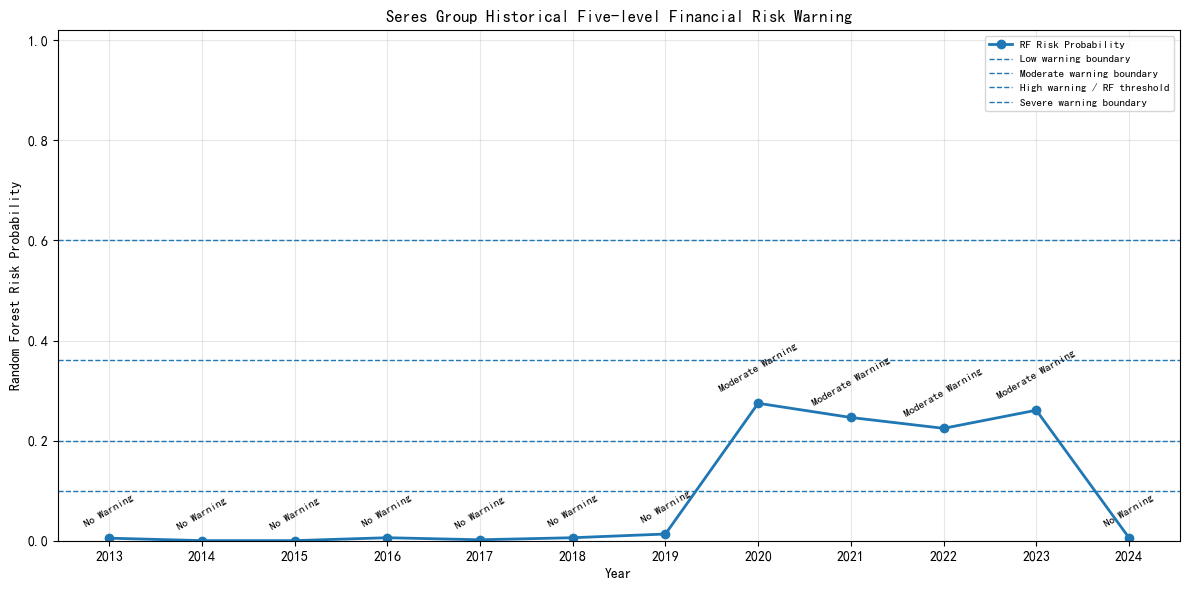

In [32]:
# =============================================================
# Visualise Seres historical risk probability and warning bands
# =============================================================
import matplotlib.pyplot as plt

plot_data = seres_results.dropna(subset=["Year", "RF_Risk_Probability"]).copy()

plt.figure(figsize=(12, 6))
plt.plot(
    plot_data["Year"],
    plot_data["RF_Risk_Probability"],
    marker="o",
    linewidth=2,
    label="RF Risk Probability"
)

# Warning boundaries
for boundary, label in [
    (0.1000, "Low warning boundary"),
    (0.2000, "Moderate warning boundary"),
    (0.3615, "High warning / RF threshold"),
    (0.6000, "Severe warning boundary")
]:
    plt.axhline(boundary, linestyle="--", linewidth=1, label=label)

# Label each annual point with its warning level
for _, row in plot_data.iterrows():
    plt.annotate(
        row["Warning_Level"],
        (row["Year"], row["RF_Risk_Probability"]),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        rotation=30
    )

plt.ylim(0, 1.02)
plt.xticks(plot_data["Year"].astype(int).tolist())
plt.xlabel("Year")
plt.ylabel("Random Forest Risk Probability")
plt.title("Seres Group Historical Five-level Financial Risk Warning")
plt.grid(alpha=0.3)
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

In [33]:
# =============================================================
# Local SHAP interpretation for Seres Group
# Example year: 2023
# =============================================================

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Select the year to be explained
EXPLAIN_YEAR = 2023

# Ensure the year variable is available
seres_raw["Year"] = pd.to_datetime(
    seres_raw["Reporting Date"], errors="coerce"
).dt.year

# Locate the Seres observation for the selected year
selected_mask = seres_raw["Year"].eq(EXPLAIN_YEAR)

if selected_mask.sum() == 0:
    raise ValueError(
        f"No Seres observation was found for {EXPLAIN_YEAR}."
    )

if selected_mask.sum() > 1:
    print(
        f"More than one Seres observation was found for {EXPLAIN_YEAR}. "
        "The first observation will be used."
    )

selected_index = seres_raw.loc[selected_mask].index[0]

# Standardised feature values used by the Random Forest model
X_seres_selected = seres_features_scaled.loc[[selected_index]].copy()

# Original feature values, used only for displaying readable values
X_seres_selected_original = seres_features.loc[[selected_index]].copy()

# Confirm the model prediction
selected_probability = rf.predict_proba(X_seres_selected)[0, 1]

print(f"Selected year: {EXPLAIN_YEAR}")
print(f"Random Forest risk probability: {selected_probability:.4f}")
print(f"Warning level: {assign_warning_level(selected_probability)}")

Selected year: 2023
Random Forest risk probability: 0.2608
Warning level: Moderate Warning


In [34]:
# =============================================================
# Calculate local SHAP values
# Positive class: Financial Risk = 1
# =============================================================

explainer_local = shap.TreeExplainer(rf)

raw_shap_values = explainer_local.shap_values(X_seres_selected)

# Handle different SHAP output formats
if isinstance(raw_shap_values, list):
    # Older SHAP versions:
    # [SHAP values for class 0, SHAP values for class 1]
    local_shap_values = raw_shap_values[1][0]
    local_base_value = explainer_local.expected_value[1]

elif np.asarray(raw_shap_values).ndim == 3:
    # Newer SHAP versions:
    # shape may be (samples, features, classes)
    local_shap_values = np.asarray(raw_shap_values)[0, :, 1]

    expected_value = np.asarray(explainer_local.expected_value)
    if expected_value.ndim == 0:
        local_base_value = float(expected_value)
    else:
        local_base_value = expected_value[1]

else:
    # Binary output returned directly
    local_shap_values = np.asarray(raw_shap_values)[0]

    expected_value = np.asarray(explainer_local.expected_value)
    if expected_value.ndim == 0:
        local_base_value = float(expected_value)
    else:
        local_base_value = expected_value[-1]

print("Base value:", local_base_value)
print("Number of SHAP values:", len(local_shap_values))

Base value: 0.5003474282888228
Number of SHAP values: 17


In [ ]:
# =============================================================
# SHAP Waterfall Plot for Seres Group
# =============================================================

local_explanation = shap.Explanation(
    values=local_shap_values,
    base_values=local_base_value,
    data=X_seres_selected_original.iloc[0].values,
    feature_names=feature_cols.tolist()
)

plt.figure(figsize=(10, 7))

shap.plots.waterfall(
    local_explanation,
    max_display=12,
    show=False
)

plt.title(
    f"SHAP Waterfall Plot for Seres Group ({EXPLAIN_YEAR})",
    fontsize=14,
    pad=20
)

plt.tight_layout()

plt.savefig(
    f"Seres_{EXPLAIN_YEAR}_SHAP_Waterfall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
# =============================================================
# SHAP Force Plot for Seres Group
# =============================================================

shap.initjs()

force_plot = shap.force_plot(
    local_base_value,
    local_shap_values,
    X_seres_selected_original.iloc[0],
    feature_names=feature_cols.tolist(),
    matplotlib=False
)

force_plot

In [37]:
# =============================================================
# SHAP contribution table
# =============================================================

seres_shap_table = pd.DataFrame({
    "Feature": feature_cols,
    "Original_Value": X_seres_selected_original.iloc[0].values,
    "SHAP_Value": local_shap_values
})

seres_shap_table["Absolute_SHAP_Value"] = (
    seres_shap_table["SHAP_Value"].abs()
)

seres_shap_table["Risk_Direction"] = np.where(
    seres_shap_table["SHAP_Value"] > 0,
    "Increases predicted risk",
    "Decreases predicted risk"
)

seres_shap_table = seres_shap_table.sort_values(
    "Absolute_SHAP_Value",
    ascending=False
).reset_index(drop=True)

display(seres_shap_table.head(12))

seres_shap_table.to_excel(
    f"Seres_{EXPLAIN_YEAR}_Local_SHAP_Contributions.xlsx",
    index=False
)

,Feature,Original_Value,SHAP_Value,Absolute_SHAP_Value,Risk_Direction
0,Total Asset Turnover,0.699428,-0.125108,0.125108,Decreases predicted risk
1,Firm Size,24.659877,-0.089382,0.089382,Decreases predicted risk
2,Total Asset Cash Recovery Rate,0.124844,-0.084946,0.084946,Decreases predicted risk
3,Return on Equity (ROE),-0.577326,0.071812,0.071812,Increases predicted risk
4,Total Asset Growth Rate,0.089209,-0.054904,0.054904,Decreases predicted risk
5,Accounts Receivable Turnover,14.653677,-0.044486,0.044486,Decreases predicted risk
6,Return on Asset(ROA),-0.081115,0.041769,0.041769,Increases predicted risk
7,Revenue Growth Rate,1.465537,0.039249,0.039249,Increases predicted risk
8,Capital Accumulation Rate,-0.265497,0.038103,0.038103,Increases predicted risk
9,Profit-to-Cost Ratio,-0.097577,0.034137,0.034137,Increases predicted risk
